In [2]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import os
import sys
import json
import wandb
import torch.nn as nn
from torch.utils.data import DataLoader

notebook_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(notebook_dir, '..'))
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)
print(sys.path)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

%load_ext autoreload
%autoreload 2

['/mnt/ceph/users/blyo1/projects', '/mnt/sw/nix/store/71ksmx7k6xy3v9ksfkv5mp5kxxp64pd6-python-3.10.13-view/lib/python310.zip', '/mnt/sw/nix/store/71ksmx7k6xy3v9ksfkv5mp5kxxp64pd6-python-3.10.13-view/lib/python3.10', '/mnt/sw/nix/store/71ksmx7k6xy3v9ksfkv5mp5kxxp64pd6-python-3.10.13-view/lib/python3.10/lib-dynload', '', '/mnt/home/blyo1/venvs/py310/lib/python3.10/site-packages']
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# load the model weights

In [3]:
from b_models.configs.sami_config import SAMI_Simple_Disk_Training_Config
from utils.wandb_utils import get_wandb_run_name, get_artifact

project_name = "sami_simple_disk"
model_num = 22

# construct config from wandb run
model_path, artifact, config, run_config = get_artifact(model_num=model_num, project_name=project_name)
config = SAMI_Simple_Disk_Training_Config.from_dict(run_config)

/mnt/home/blyo1/venvs/py310/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/mnt/home/blyo1/hdiva/c_training/lightning_checkpoints/sami_simple_disk
wandb run name: th7a3ex7


wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb:   1 of 1 files downloaded.  


In [4]:
from b_models.sami.sami_lightning import SAMI_Lightning
from b_models.sami.sami_inference import SAMI_Inference

lightning_model = SAMI_Lightning.load_from_checkpoint(checkpoint_path=model_path, config=config)
sami_inference = SAMI_Inference(sami=lightning_model.model, config=config).to(device)

/mnt/home/blyo1/hdiva/c_training/lightning_checkpoints/ddpm_simple_disk
wandb run name: xmbjtmxg


wandb:   1 of 1 files downloaded.  


Loaded denoiser weights from wandb artifact_id v23


## (optional) check that the denoiser weights in SAMI are not the same as those in preloaded DDPM

In [34]:
# compare the denoiser weights in SAMI_Lightning vs denoiser weights in DDPM
sami_example_weight = lightning_model.model.denoiser.final.conv.weight

In [26]:
from b_models.configs.ddpm_config import DDPM_Simple_Disk_Training_Config
from utils.wandb_utils import get_wandb_run_name, get_artifact

project_name = "ddpm_simple_disk"
model_num = 2

# construct config from wandb run
model_path, artifact, config, run_config = get_artifact(model_num=model_num, project_name=project_name)
config = DDPM_Simple_Disk_Training_Config.from_dict(run_config)

from b_models.ddpm.ddpm_lightning import DDPM_Lightning
from b_models.ddpm.ddpm_inference import DDPM_Inference

lightning_ddpm = DDPM_Lightning.load_from_checkpoint(checkpoint_path=model_path, config=config)
ddpm_inference = DDPM_Inference(ddpm=lightning_ddpm.model, config=config).to(device)

/mnt/home/blyo1/hdiva/c_training/lightning_checkpoints/ddpm_simple_disk
wandb run name: xmbjtmxg


wandb:   1 of 1 files downloaded.  


In [35]:
ddpm_example_weight = lightning_ddpm.model.denoiser.final.conv.weight

In [36]:
torch.equal(sami_example_weight, ddpm_example_weight)

False

# load the dataset

In [5]:
from a_datasets.sos.data import load_sos_data
from a_datasets.disks.data import load_simple_disk_dataset

cpu_tensor, _ = load_simple_disk_dataset(
    num_samples=1000,
    img_size=config.image_dim, 
    foreground=config.foreground,
    background=config.background,
    outer_radius=config.outer_radius, 
    transition_width=config.transition_width,
    seed=config.dataset_seed,
    cx_range=(10, 18)
)
print(cpu_tensor.shape)
print(cpu_tensor.min(), cpu_tensor.max())
print(config.dataset_size)


torch.Size([1000, 1, 28, 28])
tensor(0.) tensor(1.)
100000


In [6]:
from torchvision import transforms

from a_datasets.custom_dataset_classes import CustomTensorDataset

transform = transforms.Compose(
    [
        transforms.Normalize((0.5,), (0.5,)),
    ]
)
train_dataset = CustomTensorDataset(cpu_tensor, transform)

input_img = train_dataset[31]
print(input_img.shape)
print(input_img.min())
print(input_img.max())


torch.Size([1, 28, 28])
tensor(-1.)
tensor(1.)


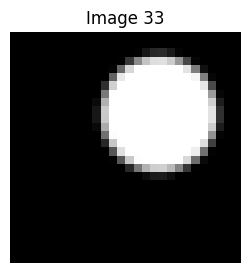

-1.0 1.0
---
-1.0 1.0


In [7]:
from utils.base_utils import t2n, to_01

"""select an image from cis dataset"""
img_idx = 33
target_img = t2n(train_dataset[img_idx])
target_img = np.transpose(target_img, (1,2,0))

fig, ax = plt.subplots(1, 1, figsize=(3, 3))
ax.imshow(target_img, cmap='gray', vmin=-1, vmax=1)
ax.axis('off')
ax.set_title(f"Image {img_idx}")
plt.show()

print(train_dataset[img_idx].min().item(), train_dataset[img_idx].max().item())
print('---')
print(target_img.min(), target_img.max())

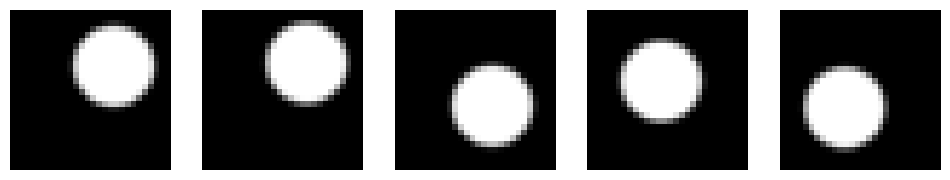

In [24]:
from utils.base_utils import t2n, to_01

"""select an image from cis dataset"""
img_idx = [33, 34, 35, 36, 37]
imgs = []
for idx in img_idx:
    target_img = t2n(train_dataset[idx])
    target_img = np.transpose(target_img, (1,2,0))
    imgs.append(target_img)


fig, ax = plt.subplots(1, len(img_idx), figsize=(12, 3))
for i, (idx, img) in enumerate(zip(img_idx, imgs)):
    ax[i].imshow(img, cmap='gray', vmin=-1, vmax=1)
    ax[i].axis('off')
plt.show()

# conditional generation

In [8]:
"""generate images from sami_inference"""
sami_inference.conditional_sample(N=4, target_image_input=train_dataset[img_idx].unsqueeze(0), return_chain=False)
gen_img = sami_inference.x_t
print(gen_img.shape)
print(gen_img.min(), gen_img.max())

torch.Size([4, 1, 28, 28])
tensor(-1.4495, device='cuda:0') tensor(1.4484, device='cuda:0')


(28, 28, 1)
(4, 28, 28, 1)
-0.22476476 1.2241957


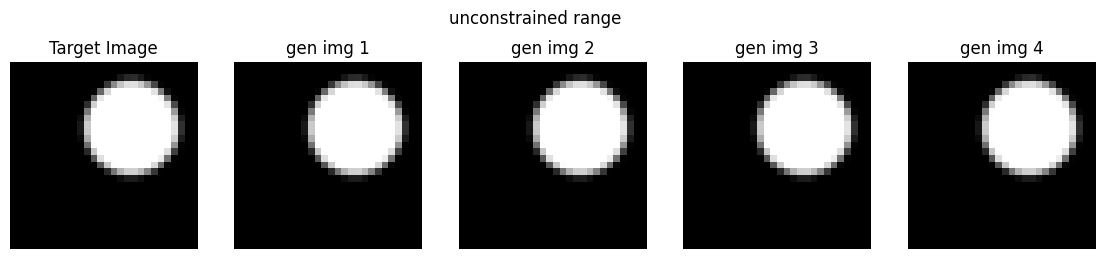

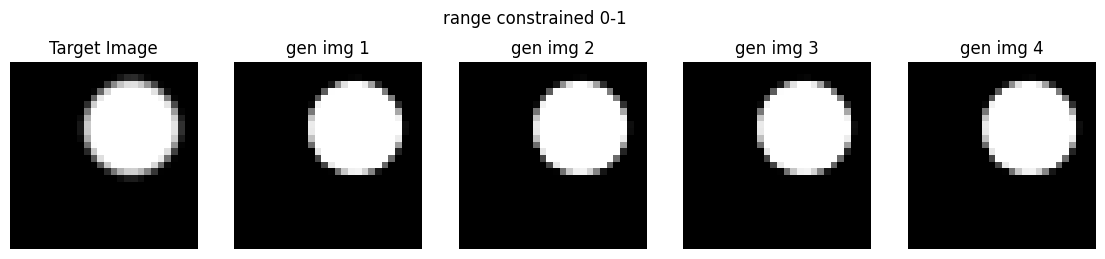

In [9]:
# figure
target_img = t2n(train_dataset[img_idx])
target_img = np.transpose(target_img, (1,2,0))
target_img = to_01(target_img)
print(target_img.shape)

gen_img_np = t2n(gen_img)
gen_img_np = np.transpose(gen_img_np, (0,2,3,1))
gen_img_np = to_01(gen_img_np)
print(gen_img_np.shape)
print(gen_img_np.min(), gen_img_np.max())


fig, ax = plt.subplots(1,5, figsize=(14,3))
ax[0].imshow(target_img, vmin=0, vmax=1, cmap='gray')
ax[0].axis('off')
ax[0].set_title('Target Image')
for i in range(1,5):
    # ax[i].imshow(gen_img_np[i-1], vmin=0, vmax=1, cmap='gray')
    ax[i].imshow(gen_img_np[i-1], cmap='gray')
    ax[i].axis('off')
    ax[i].set_title(f'gen img {i}')
fig.suptitle('unconstrained range')
plt.show()

fig, ax = plt.subplots(1,5, figsize=(14,3))
ax[0].imshow(target_img, vmin=0, vmax=1, cmap='gray')
ax[0].axis('off')
ax[0].set_title('Target Image')
for i in range(1,5):
    ax[i].imshow(gen_img_np[i-1], vmin=0, vmax=1, cmap='gray')
    # ax[i].imshow(gen_img_np[i-1], cmap='gray')
    ax[i].axis('off')
    ax[i].set_title(f'gen img {i}')
fig.suptitle('range constrained 0-1')
# fig.tight_layout()
plt.show()
# ax[1].axis('off')
# ax[1].set_title('Generated Image')

# check disentanglement

In [10]:
from a_datasets.disks.disks import make_disk_vectorized

img_size = 28
outer_radius = 6
transition_width = 2
foreground = 1.
background = 0.

c_x = 22
c_y = 22

c_min = outer_radius
c_max = img_size - outer_radius

assert c_x >= c_min and c_x <= c_max
assert c_y >= c_min and c_y <= c_max

# cx = (c_x - c_min) / (c_max - c_min) * 2 - 1
# cy = (c_y - c_min) / (c_max - c_min) * 2 - 1

# print(cx)

disk = make_disk_vectorized(
    (img_size, img_size),
    outer_radius,
    transition_width,
    foreground=foreground,
    background=background,
    c_x=c_x,
    c_y=c_y,
)[0]

torch.Size([28, 28])


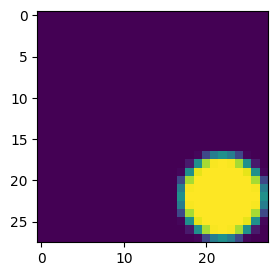

In [11]:
print(disk.shape)

plots=(1, 1)
fig, ax = plt.subplots(*plots, figsize=(plots[-1]*3, 3))
ax.imshow(disk)

In [12]:
from a_datasets.disks.disks import make_disk_vectorized

def get_disks_along_one_dim(varying_dim='x', fixed_dim_value=28, num_vals=10, img_size=28, outer_radius=6, transition_width=2, foreground=1, background=0):
    """Produce {num_vals} disk images where we vary the centers along the {dim} dimension. 
    The other dimension is fixed to be {value}.
    """
    c_min = outer_radius
    c_max = img_size - outer_radius
    if varying_dim=='x':
        c_ys = [fixed_dim_value]
        c_xs = np.linspace(c_min, c_max, num_vals)
        
    elif varying_dim=='y':
        c_xs = [fixed_dim_value]
        c_ys = np.linspace(c_min, c_max, num_vals)

    disks = []

    for c_x in c_xs:
        for c_y in c_ys:
            assert c_x >= c_min and c_x <= c_max
            assert c_y >= c_min and c_y <= c_max
            disk = make_disk_vectorized(
                (img_size, img_size),
                outer_radius,
                transition_width,
                foreground=foreground,
                background=background,
                c_x=c_x,
                c_y=c_y,
            )[0]
            disks.append(disk)
    
    disks = torch.stack(disks)

    return disks

disks = get_disks_along_one_dim(varying_dim='x', fixed_dim_value=20, num_vals=10)

In [13]:
print(disks.shape)
print(disks.min(), disks.max())

torch.Size([10, 28, 28])
tensor(0.) tensor(1.)


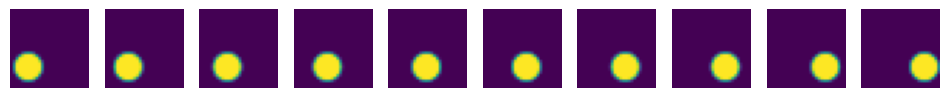

In [14]:
fig, ax = plt.subplots(1, len(disks), figsize=(12, 3))
for i in range(len(disks)):
    ax[i].imshow(disks[i])
    ax[i].axis('off')

In [15]:
disks_normalized = (disks * 2 - 1).unsqueeze(1)
print(disks_normalized.shape)
print(disks_normalized.min(), disks_normalized.max())

torch.Size([10, 1, 28, 28])
tensor(-1.) tensor(1.)


In [16]:
# now plug this into the latent space
enc = sami_inference.infnet

mu, logvar = enc(disks_normalized.to(device))
z = enc.sample(mu, logvar)

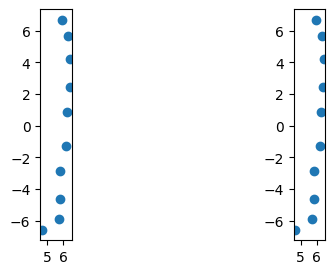

In [17]:
z_cpu = z.detach().cpu().numpy()
mu_cpu = mu.detach().cpu().numpy()

plots=(1, 2)
fig, ax = plt.subplots(*plots, figsize=(plots[-1]*3, 3))
ax[0].scatter(*z_cpu.T)
ax[0].set_aspect('equal')

ax[1].scatter(*mu_cpu.T)
ax[1].set_aspect('equal')


now repeat this for many values of x

In [18]:
c_min = 6
c_max = 28-6
c_ys = np.linspace(c_min, c_max, 10)

all_disks = []

for c_y in c_ys:
    disks = get_disks_along_one_dim(varying_dim='x', fixed_dim_value=c_y, num_vals=10)
    all_disks.append(disks)

all_disks = torch.stack(all_disks)
print(all_disks.shape)

torch.Size([10, 10, 28, 28])


In [19]:
all_disks_normalized = (all_disks * 2 - 1).unsqueeze(2)
print(all_disks_normalized.shape)
print(all_disks_normalized.min(), all_disks_normalized.max())

# now plug this into the latent space
enc = sami_inference.infnet

all_mus = []
all_zs = []
for i in range(all_disks_normalized.shape[0]):
    mu, logvar = enc(all_disks_normalized[i].to(device))
    z = enc.sample(mu, logvar)

    all_mus.append(mu)
    all_zs.append(z)
all_mus = torch.stack(all_mus)
all_zs = torch.stack(all_zs)

all_mus_cpu = all_mus.detach().cpu().numpy()
all_zs_cpu = all_zs.detach().cpu().numpy()

print(all_zs_cpu.shape)

torch.Size([10, 10, 1, 28, 28])
tensor(-1.) tensor(1.)
(10, 10, 2)


In [20]:
for c in plt.cm.tab10.colors:
    print(c)

(0.12156862745098039, 0.4666666666666667, 0.7058823529411765)
(1.0, 0.4980392156862745, 0.054901960784313725)
(0.17254901960784313, 0.6274509803921569, 0.17254901960784313)
(0.8392156862745098, 0.15294117647058825, 0.1568627450980392)
(0.5803921568627451, 0.403921568627451, 0.7411764705882353)
(0.5490196078431373, 0.33725490196078434, 0.29411764705882354)
(0.8901960784313725, 0.4666666666666667, 0.7607843137254902)
(0.4980392156862745, 0.4980392156862745, 0.4980392156862745)
(0.7372549019607844, 0.7411764705882353, 0.13333333333333333)
(0.09019607843137255, 0.7450980392156863, 0.8117647058823529)


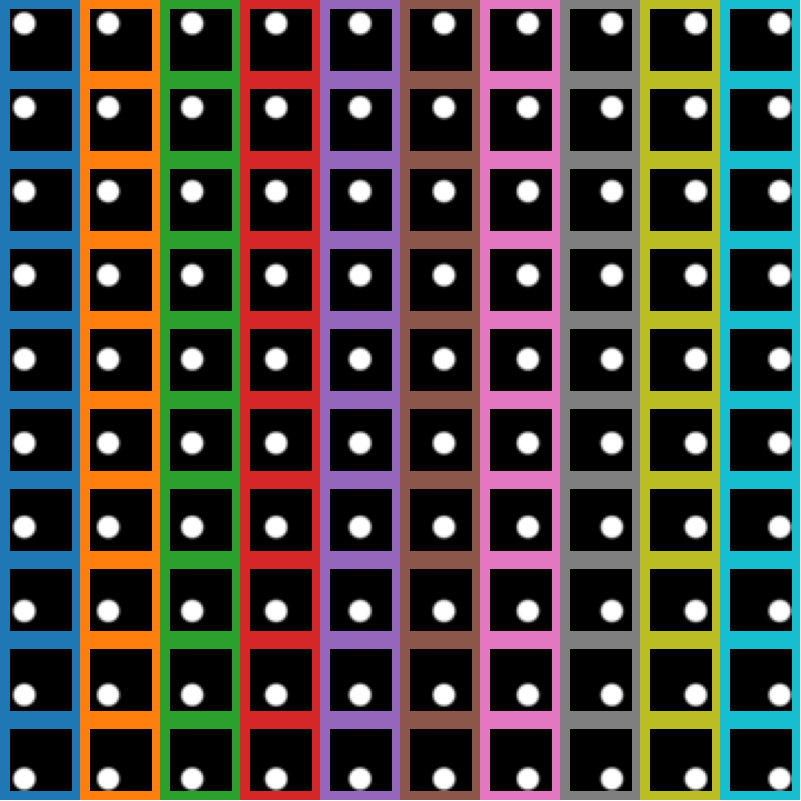

In [21]:
fig = plt.figure(figsize=(8,8))
subfigs = fig.subfigures(ncols=10,nrows=10)

images = []
for i in range(all_disks.shape[0]):
    for j in range(all_disks.shape[1]): 
        axs = subfigs[i][j].subplots()
        data = all_disks[i,j]
        images.append(axs.imshow(data, cmap='grey'))
        axs.label_outer()
        axs.axis('off')

        if i==j:
            pass
            # subfigs[i][j].set_facecolor("red")
        # if i % 10 == 0:
        subfigs[i][j].set_facecolor(plt.cm.tab10.colors[j])

plt.show()


Text(0.5, 1.0, '2d latent responses')

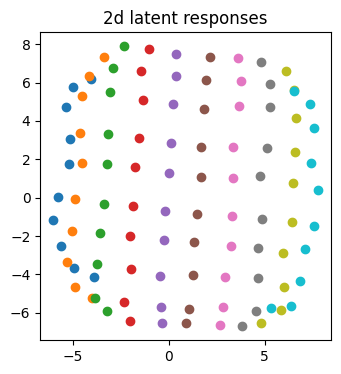

In [22]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))

for i in range(all_mus.shape[0]):
    ax.scatter(*all_mus_cpu[i].T)
    ax.set_aspect('equal')
ax.set_title('2d latent responses')

## now vary the intensity

In [ ]:
from a_datasets.disks.disks import make_disk_vectorized

def get_disks_along_one_dim(varying_dim='x', fixed_dim_value=28, num_vals=10, img_size=28, outer_radius=6, transition_width=2, foreground=1, background=0):
    """Produce {num_vals} disk images where we vary the centers along the {dim} dimension. 
    The other dimension is fixed to be {value}.
    """
    c_min = outer_radius
    c_max = img_size - outer_radius
    if varying_dim=='x':
        c_ys = [fixed_dim_value]
        c_xs = np.linspace(c_min, c_max, num_vals)
        
    elif varying_dim=='y':
        c_xs = [fixed_dim_value]
        c_ys = np.linspace(c_min, c_max, num_vals)
    
    elif varying_dim=='xz' or varying_dim=='zx':
        c_xs = [fixed_dim_value]
        # c_ys = np.linspace(c_min, c_max, num_vals)
        c_zs = []

    disks = []

    for c_x in c_xs:
        for c_y in c_ys:
            assert c_x >= c_min and c_x <= c_max
            assert c_y >= c_min and c_y <= c_max
            disk = make_disk_vectorized(
                (img_size, img_size),
                outer_radius,
                transition_width,
                foreground=foreground,
                background=background,
                c_x=c_x,
                c_y=c_y,
            )[0]
            disks.append(disk)
    
    disks = torch.stack(disks)

    return disks

disks = get_disks_along_one_dim(varying_dim='x', fixed_dim_value=20, num_vals=10)

# 3d plot